### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

### Read file and initial processing

In [3]:
#Read csv
df = pd.read_csv("../Data/HISTDATA_COM_ASCII_EURUSD_T202601/DAT_ASCII_EURUSD_T_202601.csv", header=None)
#Make column names
df.columns = ["datetime", "bid", "ask", "volume"]
#Convert date-time to date-time format
df["datetime"] = pd.to_datetime(df["datetime"], format="%Y%m%d %H%M%S%f")
#Compute mid-price
df["mid"] = (df["bid"] + df["ask"]) / 2
print(df.head(5))


                 datetime      bid      ask  volume       mid
0 2026-01-01 17:04:01.135  1.17387  1.17532       0  1.174595
1 2026-01-01 17:04:37.436  1.17414  1.17531       0  1.174725
2 2026-01-01 17:05:00.073  1.17414  1.17517       0  1.174655
3 2026-01-01 17:05:00.283  1.17449  1.17523       0  1.174860
4 2026-01-01 17:05:01.142  1.17449  1.17518       0  1.174835


### Plot arbitrary day

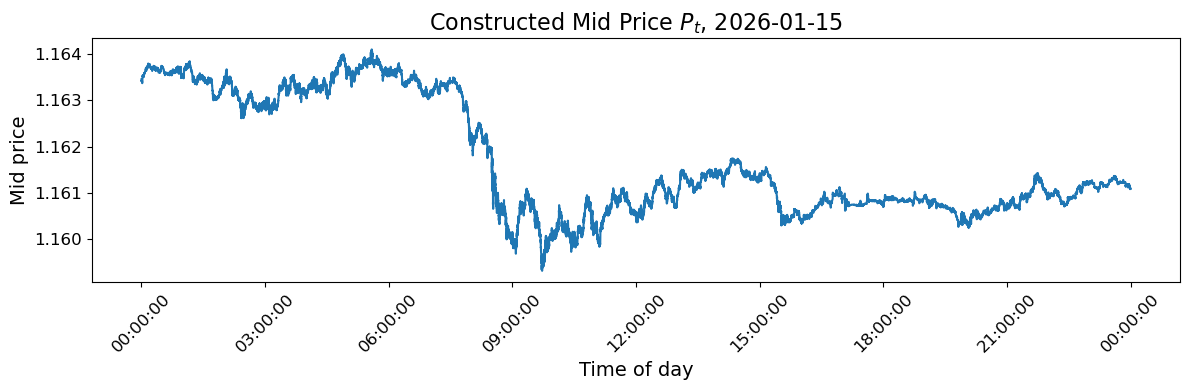

In [4]:
# Plot
dato = "2026-01-15"
df_day = df[df["datetime"].dt.date == pd.to_datetime(dato).date()]

plt.figure(figsize=(12, 4))  # Gjør figuren bred (landskapsformat)

plt.plot(df_day["datetime"], df_day["mid"])

plt.xlabel("Time of day", fontsize="14")
plt.ylabel("Mid price", fontsize="14")
plt.title(f"Constructed Mid Price $P_t$, {dato}", fontsize="16")

# Vis kun klokkeslett på x-aksen
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

plt.xticks(rotation=45, fontsize="12")
plt.yticks(fontsize="12")
plt.tight_layout()
plt.show()


### Pre-Averaging and Constructing Returns

In [5]:
#print(df.head(5))

### Begin pre-averaging ###
k = 5
df["P_bar"] = df["mid"].rolling(window=k).mean()
df = df.dropna(subset=["P_bar"]).reset_index(drop=True)
#print(df.head(3))

### Construct returns ###
df["r"] = df["P_bar"].diff()
#print(df.head(3))

### Choose data from one day
start = "2026-01-11"
slutt = "2026-01-12"
df_day = df[(df["datetime"] >= start) & (df["datetime"] < slutt)]
# print(df_day.head(2))
# print(df_day.tail(2))
# print(len(df_day))

# Set datetime as index
if "datetime" in df_day.columns:
    df_day = df_day.set_index("datetime")
df_day = df_day.sort_index()

# print(df_day.head(2))

groups_5min = df_day.groupby(pd.Grouper(freq="5min"))


In [6]:
import statsmodels.api as sm

phi_list = []

for t, g in groups_5min:
    y = g["r"].iloc[1:]          # r_t
    x = g["r"].shift(1).iloc[1:] # r_{t-1}

    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    phi = model.params[1]        # koeffisienten til lag1

    phi_list.append((t, phi))    # (interval_start, phi)



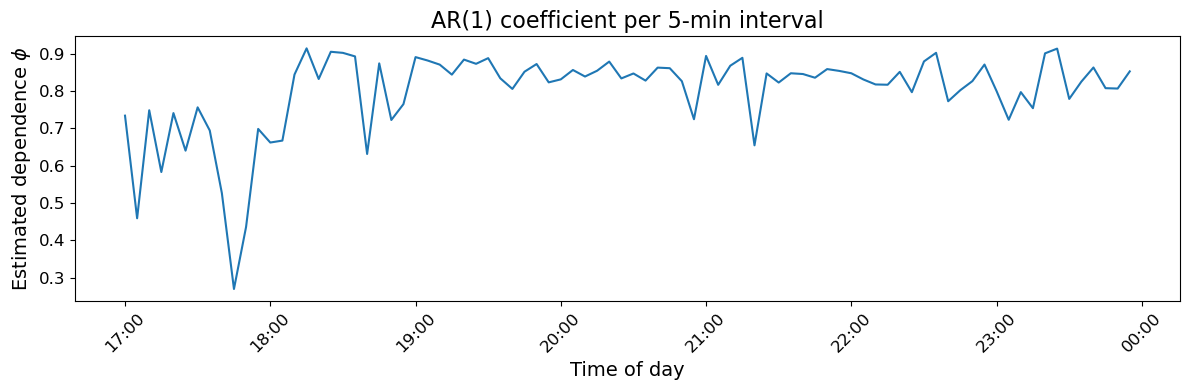

In [ ]:
# Gjør om til Series
phi_series = pd.Series(dict(phi_list)).sort_index()

# Plot
plt.figure(figsize=(12,4))
plt.plot(phi_series.index, phi_series.values)

# Kun klokkeslett på x-aksen
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.xlabel("Time of day", fontsize=14)
plt.ylabel("Estimated dependence $\phi$", fontsize=14)
plt.title("AR(1) coefficient $\phi$ per 5-min interval", fontsize=16)

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

In [8]:
# Define avg. block size:
k=20 

#Sort data chronologically
df = df.sort_values("datetime").reset_index(drop=True)

# Pre-averaging
df["P_bar"] = df["mid"].rolling(window=k).mean()

# Remove NaNs
df = df.dropna(subset=["P_bar"]).reset_index(drop=True)

# Construct returns
df["r"] = df["P_bar"].diff()
# Remove NaNs
df = df.dropna(subset=["r"]).reset_index(drop=True)

#Sanity check:
print(df.head(10))

                 datetime      bid      ask  volume       mid     P_bar  \
0 2026-01-01 17:10:31.468  1.17477  1.17522       0  1.174995  1.174863   
1 2026-01-01 17:10:46.029  1.17477  1.17516       0  1.174965  1.174870   
2 2026-01-01 17:11:02.773  1.17478  1.17521       0  1.174995  1.174878   
3 2026-01-01 17:11:02.877  1.17476  1.17521       0  1.174985  1.174885   
4 2026-01-01 17:11:12.785  1.17475  1.17521       0  1.174980  1.174888   
5 2026-01-01 17:11:18.468  1.17475  1.17523       0  1.174990  1.174892   
6 2026-01-01 17:11:19.975  1.17475  1.17524       0  1.174995  1.174897   
7 2026-01-01 17:11:26.316  1.17476  1.17524       0  1.175000  1.174907   
8 2026-01-01 17:11:56.902  1.17476  1.17523       0  1.174995  1.174917   
9 2026-01-01 17:12:12.284  1.17475  1.17523       0  1.174990  1.174926   

          r  
0  0.000008  
1  0.000007  
2  0.000009  
3  0.000007  
4  0.000003  
5  0.000005  
6  0.000004  
7  0.000010  
8  0.000011  
9  0.000009  
